# Data Preprocessing

---

In [43]:
from pathlib import Path

if not Path("./data/Ubuntu-dialogue-corpus").exists():
    !kaggle datasets download rtatman/ubuntu-dialogue-corpus -p data --unzip

This dataset is huge! 26 million turns spread across three csv files! The `dialogueText.csv` is around 111MB, containing around 1M turns. For some context, turns are single messages in a conversation thread, so preserving order is essential (each message is a reply to the previous one).

The following cell prints some basic statistics of the `dialogueText.csv`.

In [44]:
import pandas as pd
pd.set_option('display.max_colwidth', None)

df = pd.read_csv('./data/Ubuntu-dialogue-corpus/dialogueText.csv')
print(f'Shape: {df.shape}')
print(f'\nColumns: {df.columns.tolist()}')
print(f'\nNull counts:\n{df.isnull().sum()}')
df.head(5)

Shape: (1038324, 6)

Columns: ['folder', 'dialogueID', 'date', 'from', 'to', 'text']

Null counts:
folder             0
dialogueID         0
date               0
from              13
to            472289
text              89
dtype: int64


,folder,dialogueID,date,from,to,text
0,3,126125.tsv,2008-04-23T14:55:00.000Z,bad_image,NaN,"Hello folks, please help me a bit with the following sentence: 'Order here your personal photos or videos.' - I think the only allowed version is 'Order your personal videos or photos here.', but I'm not sure, are you?"
1,3,126125.tsv,2008-04-23T14:56:00.000Z,bad_image,NaN,Did I choose a bad channel? I ask because you seem to be dumb like windows user
2,3,126125.tsv,2008-04-23T14:57:00.000Z,lordleemo,bad_image,the second sentence is better english and we are not dumb
3,3,64545.tsv,2009-08-01T06:22:00.000Z,mechtech,NaN,Sock Puppe?t
4,3,64545.tsv,2009-08-01T06:22:00.000Z,mechtech,NaN,WTF?


Read the [Kaggle dataset description](https://www.kaggle.com/datasets/rtatman/ubuntu-dialogue-corpus):
- `to` has ~470k nulls, which corresponds to messages not directed towards a particular user (no need to drop these for pair extraction).
- `text` and `from` have very few nulls relative to the dataset size. The consequence of dropping these rows is trivial. 

## Sorting

---

In [45]:
# Drop the rows with missing text or from values 
df = df.dropna(subset=['text', 'from']).reset_index(drop=True)

# Sort by date to preserve order
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['folder', 'dialogueID', 'date']).reset_index(drop=True)

print(f'New shape: {df.shape}')

New shape: (1038222, 6)


## Create Dialogue Pairs

---

We need to preserve the order of turns within dialogues. With the dataset sorted by `folder`, `dialogue` and then `date`, we can group related conversations and construct consecutive pairs. Our dataset train samples will be these consecutive dialogue pairs. Here is a concrete example:

Turn 1 (input):   "Hello folks, please help me with the following..."
Turn 2 (target):  "the second sentence is better english and we..."

The input sequence is fed into the encoder, the decoder must learn to produce the target sequence from the encoder's output hidden state. 

**NOTE!** These Ubuntu conversation threads are not always going to have clean question/answer formats (for example, there are some funny instances of people talking to themselves alone in a thread before others reply). To account for this, here are two options that would use a filter where the sender changes so that pairs are constructed using _actual_ replies:
- A. Use the last message from a user before the sender changes (simpler, but results in potential information loss). Note we could also take the first message. It would depend where the most context would likely be in a block of consecutive messages from one user.
- B. Concatenate all preceding messages from a user before the sender changes

The below preprocessing proceeds with option A.

In [46]:
# Pairing with context
# The original implementation ignored who exactly sent the message by bulding context windows by index order 
# This new implementation tries to differentiate the response sender from the last context sender
# It shouldn't take more than a few minutes to run

# v1: (433329, 2)
# v2: (346004, 2)
# v3: (93435, 2)
# v4: (433346, 2)

def construct_pairs_with_context(df):

    pairs = []
    grouped = df.groupby(['folder', 'dialogueID'])

    for _, dialogue in grouped:

        dialogue = dialogue.reset_index(drop=True)

        # Collapsing consecutive messages from the same sender
        turns = []
        current_sender = None
        current_msgs = []

        for _, row in dialogue.iterrows():

            sender = row['from']
            text = str(row['text']).strip()

            if not text:
                continue

            if sender == current_sender:
                current_msgs.append(text)
            else:
                if current_msgs:
                    turns.append((current_sender, " <SEP> ".join(current_msgs)))
                current_sender = sender
                current_msgs = [text]

        if current_msgs:
            turns.append((current_sender, " <SEP> ".join(current_msgs)))

        # Building the pairs
        for i in range(1, len(turns)):

            prev_sender, prev_text = turns[i-1]
            curr_sender, curr_text = turns[i]

            # Checking responder and speaker
            if prev_sender == curr_sender:
                continue

            input_text = f"<S0> {prev_text}"
            response_text = f"<S1> {curr_text}"

            pairs.append((input_text, response_text))

    return pd.DataFrame(pairs, columns=["input", "response"])

pairs_df = construct_pairs_with_context(df)
print(f'Total pairs: {pairs_df.shape}')

Total pairs: (433346, 2)


## Clean Text

---

Let's take a look at some sample pairs:

In [47]:
print(f'\nSample pairs:')
pairs_df.head(20)


Sample pairs:


,input,response
0,"<S0> Also guys, I'm trying to get into my FIrefox preferences, but it keeps telling me 'root.disabled = 'true';",<S1> are you logged in as 'root' ?
1,<S0> are you logged in as 'root' ?,<S1> no.
2,<S0> ugh ;( http://planet.ubuntulinux.org seems to be broken ;(,"<S1> perhaps if you define *broken* a little, we can help."
3,"<S0> perhaps if you define *broken* a little, we can help.","<S1> hypa7ia: Every single entry is by Tollef Fog Heen, dated November 15th. All of those are old blog entries."
4,<S0> ohh to late <SEP> http://www.ubuntulinux.org/ubuntu/login.png IS SO G-A-Y,"<S1> easy, now"
5,"<S0> see bug 67085 <SEP> sorry, typo, ignore that... try this one bug 767085",<S1> so update libc6?
6,<S0> How do I get out of this annoying unity? I can't take this anymore,<S1> sudo apt-get install gnome-shell. Unfortuately gnome-shell is pretty similar to unity but probably worse <SEP> I'd go with chromium
7,<S0> anyone know why everytime i browse my linux machine from my windows machine it asks for a login?? <SEP> but when i put the username and password for the xubuntu machine is still doesnt work,<S1> it sounds like SAMBA configuration
8,<S0> HAI THAR,<S1> go awai
9,<S0> go awai,<S1> hello


These samples are great, they look like real conversational exchanges! But... there is a lot of room for text cleaning (incorrect spelling, punctuation, embedded URLs, etc).

The degree of text cleaning is definitely something we can continue to experiment with, but I will keep this deliberately minimal now for simplicty and for another reason: Preserving the quirks of natural human conversation might produce more interesting results during model training than using simple, overly formatted question/answering responses. 

This sort of thing was what I was alluding to when I said that using the Ubuntu dataset would be more fun! Hopefully our chatbot is more conversational this way.

In [48]:
from utils import clean

pairs_df['input'] = pairs_df['input'].apply(clean)
pairs_df['response'] = pairs_df['response'].apply(clean)

print(f'\nCleaned Sample pairs:')
pairs_df.head(20)


Cleaned Sample pairs:


,input,response
0,"also guys, i'm trying to get into my firefox preferences, but it keeps telling me 'root.disabled = 'true';",are you logged in as 'root' ?
1,are you logged in as 'root' ?,no.
2,ugh ;( seems to be broken ;(,"perhaps if you define *broken* a little, we can help."
3,"perhaps if you define *broken* a little, we can help.","hypa7ia: every single entry is by tollef fog heen, dated november 15th. all of those are old blog entries."
4,ohh to late is so g-a-y,"easy, now"
5,"see bug 67085 sorry, typo, ignore that... try this one bug 767085",so update libc6?
6,how do i get out of this annoying unity? i can't take this anymore,sudo apt-get install gnome-shell. unfortuately gnome-shell is pretty similar to unity but probably worse i'd go with chromium
7,anyone know why everytime i browse my linux machine from my windows machine it asks for a login?? but when i put the username and password for the xubuntu machine is still doesnt work,it sounds like samba configuration
8,hai thar,go awai
9,go awai,hello


## Remove Duplicate Dialogue Pairs
---

To help quantify redundancy within the dataset, we look at duplication which can contribute to memorisation.

In [49]:
duplicate_pairs = pairs_df.duplicated().sum()
print(f"Duplicate dialogue pairs: {duplicate_pairs}")

Duplicate dialogue pairs: 2370


In [50]:
from utils import remove_noise

pairs_df = pairs_df[
    pairs_df['input'].apply(remove_noise) &
    pairs_df['response'].apply(remove_noise)]

pairs_df = pairs_df[pairs_df['input'] != pairs_df['response']]

pairs_df = pairs_df.reset_index(drop=True)

print("Remaining pairs after noise filtering:", len(pairs_df))
pairs_df.head()

Remaining pairs after noise filtering: 417041


,input,response
0,"also guys, i'm trying to get into my firefox preferences, but it keeps telling me 'root.disabled = 'true';",are you logged in as 'root' ?
1,are you logged in as 'root' ?,no.
2,ugh ;( seems to be broken ;(,"perhaps if you define *broken* a little, we can help."
3,"perhaps if you define *broken* a little, we can help.","hypa7ia: every single entry is by tollef fog heen, dated november 15th. all of those are old blog entries."
4,ohh to late is so g-a-y,"easy, now"


## Response Diversity Check

---
- Now that the pairs have been contextualised and deduplicated, it would be useful to examine the diversity across all responses as low diversity increases the risk of generic responses and contributes to overfitting.
- Measured on the actual training responses

In [51]:
unique_responses = pairs_df['response'].nunique()
total_responses = len(pairs_df)

print("Response diversity:")
print(f"Unique responses: {unique_responses}")
print(f"Total responses: {total_responses}")
print(f"Diversity ratio: {unique_responses/total_responses:.2%}")

Response diversity:
Unique responses: 358330
Total responses: 417041
Diversity ratio: 85.92%


## Text Length Filtering

---

Here, we can drop any pairs that are too short (noisy and providing no meaning), or too long (would slow training). Choosing a minimum and maximum sequence length depends on the distribution of text lengths for the inputs and responses in the dialogue pairs. Let's visualise it!

           input_len   response_len
count  417041.000000  417041.000000
mean       17.003988       9.973940
std        14.242651       9.083654
min         1.000000       1.000000
25%         7.000000       4.000000
50%        13.000000       7.000000
75%        22.000000      14.000000
max       204.000000     144.000000


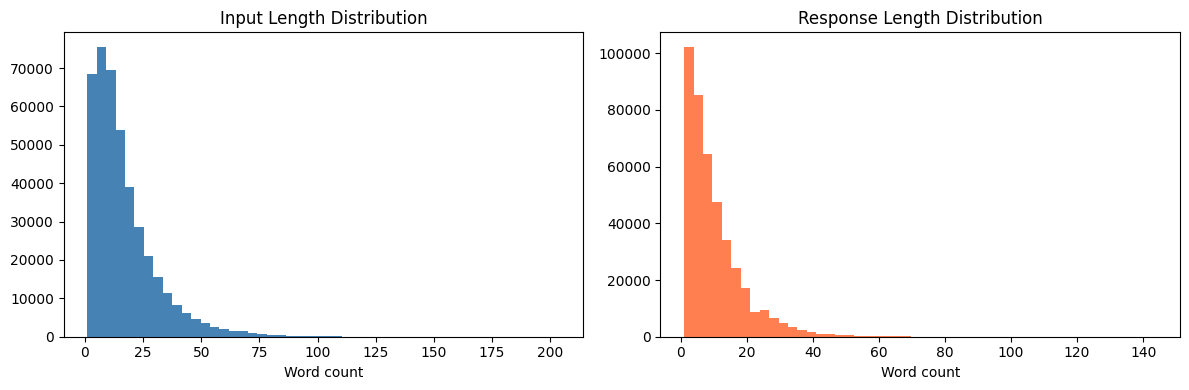

In [52]:
import matplotlib.pyplot as plt

pairs_df['input_len'] = pairs_df['input'].apply(lambda x: len(x.split()))
pairs_df['response_len'] = pairs_df['response'].apply(lambda x: len(x.split()))

print(pairs_df[['input_len', 'response_len']].describe())

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(pairs_df['input_len'], bins=50, color='steelblue')
plt.title('Input Length Distribution')
plt.xlabel('Word count')

plt.subplot(1, 2, 2)
plt.hist(pairs_df['response_len'], bins=50, color='coral')
plt.title('Response Length Distribution')
plt.xlabel('Word count')

plt.tight_layout()
plt.savefig('visualisations/1-dialogue-pair-text-lengths.png')
plt.show()

So:
- The **median** is 13 words for inputs, 7 words for responses (sequences are short and concise)
- The **75th percentile** is 22 words for inputs, 16 words for responses (most pairs are pretty short actually)
- The **maximum length** is 204 words for inputs, 144 words for responses (outliers can be trimmed)
- The **minimum length** is 1 

Let's say... 22 words for the maximum sequence length? This would cover over 75% of our data with minimal padding. We can keep the minimum length small, but certainly more than 0 to remove those pointless pairs. Let's say 2. A more performant/efficient approach would be to utilise dynamic padding (batch specific padding based on the longest sequence in the batch).

In [53]:
MIN_LENGTH = 2 # drop the short turns
MAX_LENGTH = 22 # trim the long ones

filtered_df = pairs_df[ # Using the new columns we added above
    (pairs_df['input_len'] >= MIN_LENGTH) &
    (pairs_df['response_len'] >= MIN_LENGTH) &
    (pairs_df['input_len'] <= MAX_LENGTH) &
    (pairs_df['response_len'] <= MAX_LENGTH)
].reset_index(drop=True)

# Now drop those columns as we don't want them around any longer
filtered_df = filtered_df.drop(columns=['input_len', 'response_len'])

print(f'Pairs before filtering: {len(pairs_df)}')
print(f'Pairs after filtering:  {len(filtered_df)}')
print(f'Retained: {len(filtered_df)/len(pairs_df)*100:.1f}%')
filtered_df.head(10)

Pairs before filtering: 417041
Pairs after filtering:  245954
Retained: 59.0%


,input,response
0,"also guys, i'm trying to get into my firefox preferences, but it keeps telling me 'root.disabled = 'true';",are you logged in as 'root' ?
1,ugh ;( seems to be broken ;(,"perhaps if you define *broken* a little, we can help."
2,"perhaps if you define *broken* a little, we can help.","hypa7ia: every single entry is by tollef fog heen, dated november 15th. all of those are old blog entries."
3,ohh to late is so g-a-y,"easy, now"
4,"see bug 67085 sorry, typo, ignore that... try this one bug 767085",so update libc6?
5,how do i get out of this annoying unity? i can't take this anymore,sudo apt-get install gnome-shell. unfortuately gnome-shell is pretty similar to unity but probably worse i'd go with chromium
6,hai thar,go awai
7,"if i installed another linux opperating system next to ubuntu, would it take the grub i have now and modify it?",it would install anotehr bootloader
8,it would install anotehr bootloader,like what?
9,did anyone see my question? sorry but my conenction is really sucky and i'm not sure if this is working.,"saw the question, and your second one, but no answer ;)"


We have ended up with ~260k samples in our dataset. We can work with that. Bear in mind we only started with a small fraction of the original dataset anyway!

As an aside, something I've noticed about these dialogue pairs is that some are not very coherent (see pair 9 above). These come from Ubuntu chat logs, so multiple concurrent conversations and threads involving many users is expected. We can't guarantee every turn responds in full to the previous one.

## Train/Validation/Test Splits

---

This portion of the preprocessing pipeline is usual: produce our dataset splits for training, validation and testing. Nothing special here, I'll use Scikit-Learn's `train_test_split` to do all the heavy lifting for a 80/10/10 split ratio. We don't need to stratify around any variable for this type of problem :)

In [54]:
from sklearn.model_selection import train_test_split

# Split the test set
train_val_df, test_df = train_test_split(filtered_df, test_size=0.1, random_state=42)

# Split the validation set
train_df, val_df = train_test_split(train_val_df, test_size=0.1, random_state=42)

print(f'Train:\t\t{len(train_df)} pairs ({len(train_df)/len(filtered_df)*100:.1f}%)')
print(f'Validation:\t{len(val_df)} pairs ({len(val_df)/len(filtered_df)*100:.1f}%)')
print(f'Test:\t\t{len(test_df)} pairs ({len(test_df)/len(filtered_df)*100:.1f}%)')

Train:		199222 pairs (81.0%)
Validation:	22136 pairs (9.0%)
Test:		24596 pairs (10.0%)


## Dataset Split Distribution Check
--- 
Let's compare the distribution of input and response lengths across each split to ensure the train, validation and test splits are representative of the full dataset.

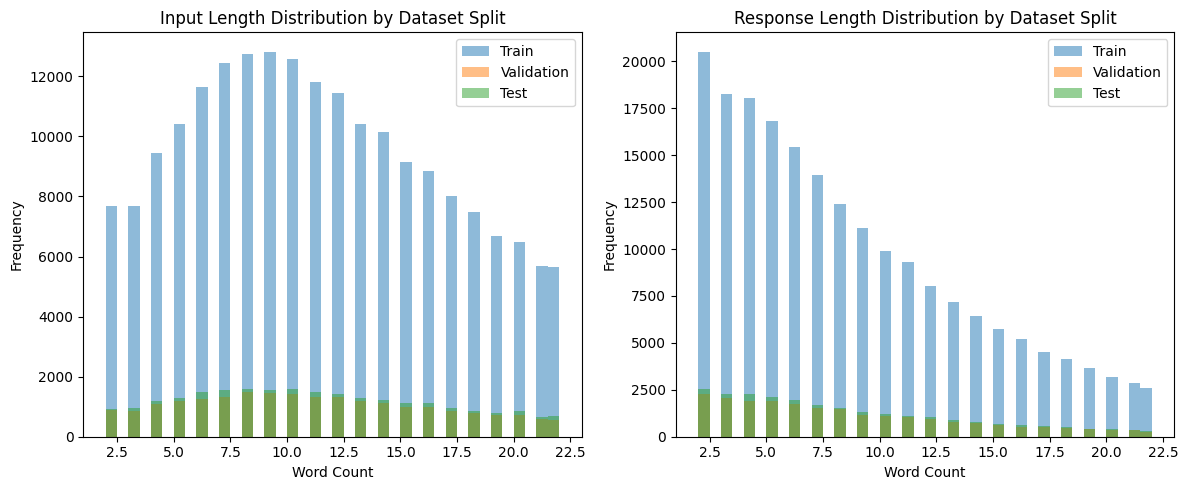

In [55]:
import matplotlib.pyplot as plt

# Compute input lengths
train_input_len = train_df['input'].apply(lambda x: len(x.split()))
val_input_len = val_df['input'].apply(lambda x: len(x.split()))
test_input_len = test_df['input'].apply(lambda x: len(x.split()))

# Compute response lengths
train_resp_len = train_df['response'].apply(lambda x: len(x.split()))
val_resp_len = val_df['response'].apply(lambda x: len(x.split()))
test_resp_len = test_df['response'].apply(lambda x: len(x.split()))

plt.figure(figsize=(12,5))

# Input length comparison
plt.subplot(1,2,1)
plt.hist(train_input_len, bins=40, alpha=0.5, label="Train")
plt.hist(val_input_len, bins=40, alpha=0.5, label="Validation")
plt.hist(test_input_len, bins=40, alpha=0.5, label="Test")
plt.title("Input Length Distribution by Dataset Split")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.legend()

# Response length comparison
plt.subplot(1,2,2)
plt.hist(train_resp_len, bins=40, alpha=0.5, label="Train")
plt.hist(val_resp_len, bins=40, alpha=0.5, label="Validation")
plt.hist(test_resp_len, bins=40, alpha=0.5, label="Test")
plt.title("Response Length Distribution by Dataset Split")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

Byte Pair Encoding (BPE)
---

In [ ]:
# Training a Byte Pair Encoding tokeniser on the training dataset only.
# This reduces Out-of-Vocabulary tokens by splitting rare technical terms into subword units.

import sentencepiece as spm
import os

# Location of the tokeniser
BPE_MODEL_PREFIX = "./data/preprocessed/bpe"
os.makedirs("./data/preprocessed", exist_ok=True)

# Combining the training text
corpus = pd.concat([train_df["input"], train_df["response"]])

# Writing the processed corpus to a new file
corpus_file = "./data/preprocessed/bpe_corpus.txt"
with open(corpus_file, "w", encoding="utf-8") as f:
    for line in corpus:
        f.write(line + "\n")

# Training the tokeniser
spm.SentencePieceTrainer.train(
    input=corpus_file,
    model_prefix=BPE_MODEL_PREFIX,
    vocab_size=24000, # based on previously agreed min_freq=5: 24083 tokens but it could be anything
    model_type="bpe",
    character_coverage=1.0,
    normalization_rule_name="identity", # running without it would break down technical terms: libstdc++6 -> lib, std, c++, 6 
    num_threads=8) # Caution: single-threaded runs of this BPE implementation will result in longer processing times!

print("BPE tokeniser trained and saved to:")
print(f"\t{BPE_MODEL_PREFIX}.model")
print(f"\t{BPE_MODEL_PREFIX}.vocab")


BPE tokeniser trained and saved to:
	./data/preprocessed/bpe.model
	./data/preprocessed/bpe.vocab


## Tokenisation and Vocabulary 

---

From here on out, everything should be familiar enough from the MMA: we need to tokenise our sequences and produce a vocabulary dictionary. To prevent data leakage, we want to build our vocabulary from the training set ONLY.

In [ ]:
# Total unique tokens: 161082
from collections import Counter
from utils import tokenise

counter = Counter()

for text in train_df['input']:
    counter.update(tokenise(text))
for text in train_df['response']:
    counter.update(tokenise(text))

print(f'Total unique tokens: {len(counter)}')
print(f'\nMost common tokens:\n{counter.most_common(40)}')
print(f'\nLeast common tokens (sample):\n{counter.most_common()[-40:]}')

Total unique tokens: 161082

Most common tokens:
[('i', 122911), ('the', 112973), ('to', 105765), ('a', 84052), ('is', 73971), ('you', 68574), ('it', 58527), ('in', 48552), ('for', 42106), ('can', 40916), ('and', 39662), ('how', 39172), ('do', 36976), ('that', 34631), ('on', 31823), ('what', 30771), ('ubuntu', 29795), ('of', 28823), ('have', 28464), ('with', 27095), ('not', 25094), ('my', 24202), ('install', 21558), ('there', 21343), ('but', 20102), ('use', 20068), ('or', 19331), ('if', 19050), ('?', 18962), ('just', 18342), ('anyone', 18138), ('are', 17243), ('be', 16201), ('know', 16153), ('me', 15667), ('does', 14799), ('from', 14740), ('your', 14406), ('get', 13609), ('any', 13024)]

Least common tokens (sample):
[("'-',", 1), ('tarelerulz:', 1), ('teasing.....', 1), ('::copy', 1), ('#ubuntu-sr', 1), ('ultra.', 1), ('did....and', 1), ('hotdog003', 1), ('`head', 1), ('-cv', 1), ('--filename', 1), ('yours.tar', 1), ('picassa', 1), ('afai', 1), ('vftp', 1), ('airplus', 1), ('forum:', 

That's a huge vocabulary! Likely many mispellings, random strings, there are even system paths scattered throughout. We need to reduce our vocabulary size. We can consider a minimum token frequency and aim for around 20k to 30k tokens in the vocabulary. This dataset likely contains lots of meaningful technical terms too. Let's see what threshold might work best:

In [15]:
for min_freq in [1, 2, 3, 5, 10]:
    vocab_size = sum(1 for _, count in counter.items() if count >= min_freq)
    print(f'min_freq={min_freq}: {vocab_size} tokens')

min_freq=1: 169409 tokens
min_freq=2: 65205 tokens
min_freq=3: 39386 tokens
min_freq=5: 25017 tokens
min_freq=10: 14602 tokens


5 seems good!

In [16]:
MIN_TOKEN_FREQ = 5

# Create the vocab dict and lets also reserve some special tokens for:
vocab = {
    '<PAD>': 0, # Padding
    '<SOS>': 1, # Start of sequence
    '<EOS>': 2, # End of sequence
    '<UNK>': 3, # Unknown token
    '<SEP>': 4, # Separator token
    '<S0>': 5,  # Speaker of context message
    '<S1>': 6   # Response sender 
}
SPECIAL_TOKENS = {'<PAD>', '<SOS>', '<EOS>', '<UNK>', '<SEP>', '<S0>', '<S1>'}

# Let's add all tokens meeting the minimum frequency to reach our rough desired token count
for word, count in counter.items():
    if word in SPECIAL_TOKENS:
        continue
    if count >= MIN_TOKEN_FREQ: # Minimum token frequency
        vocab[word] = len(vocab) # Next available idx

# Reverse the dictionary
vocab_reversed = {idx: word for word, idx in vocab.items()}

print(f'Final vocabulary size: {len(vocab)}')

Final vocabulary size: 25021


## Encoding and Padding

---

We need to convert each pair input and response to fixed-length sequences. That will involve truncating or padding each.

In [17]:
from utils import encode_sequence

# Test on the first sample
sample_input = train_df['input'].iloc[0]
sample_response = train_df['response'].iloc[0]

print(f'Original input: {sample_input}')
print(f'Encoded input: {encode_sequence(sample_input, vocab, MAX_LENGTH)}')
print(f'\nOriginal response: {sample_response}')
print(f'Encoded response: {encode_sequence(sample_response, vocab, MAX_LENGTH)}')

Original input: <S0> which tool would you recommend for html and php coding?
Encoded input: [5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Original response: <S1> vi(m) <g>
Encoded response: [6, 3, 11770, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


Looks good. 'softphone' -> 3 (`<UNK>`) -> an example of a word not in our vocabulary, that isn't frequent enough in our training set to warrant a dedicated token.

## PyTorch Dataset and DataLoader

---

The PyTorch `Dataset` will contain our training/validation set, the `DataLoader` will wrap the `Dataset` and handle batching, shuffling, parallelising, etc.

Because we're building seq2seq models with an encoder _and_ decoder, we need each sample to be: `(encoder_input, decoder_input, decoder_target)`

- `encoder_input` — encoded input sequence
- `decoder_input` — encoded response with `<SOS>` prepended
- `decoder_target` — encoded response with `<EOS>` appended

At each step, the decoder will be predicting the next token. So along with the encoder's output hidden state (or hidden states for when we train our attention model), it also needs the encoded response as input to produce an output sequence. 

In [18]:
from utils import get_dataloaders

# Batch size of 64 seems appropriate
BATCH_SIZE = 64

train_loader, val_loader, test_loader = get_dataloaders(
    train_df, 
    val_df, 
    test_df, 
    vocab, 
    MAX_LENGTH, 
    BATCH_SIZE
)

# Verify a batch
enc_batch, dec_in_batch, dec_tgt_batch = next(iter(train_loader))
print(f'Encoder input batch shape:  {enc_batch.shape}')
print(f'Decoder input batch shape:  {dec_in_batch.shape}')
print(f'Decoder target batch shape: {dec_tgt_batch.shape}')

Encoder input batch shape:  torch.Size([64, 22])
Decoder input batch shape:  torch.Size([64, 22])
Decoder target batch shape: torch.Size([64, 22])


## Done! Save to File

---

Here, I'll persist the three datasets to a preprocessed folder. Use the utility functions in `utils.py` to load the datasets, vocabulary, config and dataloaders (see `model-a.ipynb` for a working example).

In [19]:
import json
import os

PREPROCESSED_DIR = './data/preprocessed'
os.makedirs(PREPROCESSED_DIR, exist_ok=True)

# We'll save the dataset splits as CSVs
train_df.to_csv(f'{PREPROCESSED_DIR}/train.csv', index=False)
val_df.to_csv(f'{PREPROCESSED_DIR}/val.csv', index=False)
test_df.to_csv(f'{PREPROCESSED_DIR}/test.csv', index=False)

# And the vocabulary dictionaries as json files
with open('./data/preprocessed/vocab.json', 'w') as f:
    json.dump(vocab, f)

with open('./data/preprocessed/vocab_reversed.json', 'w') as f:
    json.dump(vocab_reversed, f)

# And finally a config dictionary 
config = {
    'MAX_LENGTH': MAX_LENGTH,
    'MIN_TOKEN_FREQ': MIN_TOKEN_FREQ,
    'MIN_LENGTH': MIN_LENGTH,
    'BATCH_SIZE': BATCH_SIZE,
    'VOCAB_SIZE': len(vocab),
    'PAD_IDX': vocab['<PAD>'],
    'SOS_IDX': vocab['<SOS>'],
    'EOS_IDX': vocab['<EOS>'],
    'UNK_IDX': vocab['<UNK>'],
    'SEP_IDX': vocab['<SEP>'],
    'S0_IDX': vocab['<S0>'],
    'S1_IDX': vocab['<S1>']
}
with open(f'{PREPROCESSED_DIR}/config.json', 'w') as f:
    json.dump(config, f, indent=2)

print('Saved to:')
print(f'\ttrain.csv, val.csv, test.csv ({len(train_df), len(val_df), len(test_df)} pairs)')
print(f'\tvocab.json, vocab_reversed.json ({len(vocab)} tokens)')
print(f'\tconfig.json')

Saved to:
	train.csv, val.csv, test.csv ((227250, 25250, 28056) pairs)
	vocab.json, vocab_reversed.json (25021 tokens)
	config.json


## Verification

---

In [20]:
from utils import load_sets, load_vocab, load_config, get_dataloaders

train_set, val_set, test_set = load_sets()
vocab = load_vocab()
config = load_config()

train_loader, val_loader, test_loader = get_dataloaders(
    train_set, val_set, test_set,
    vocab,
    config['MAX_LENGTH'],
    config['BATCH_SIZE']
)

In [21]:
import torch

# ── Config ───────────────────────────────────────────────────────────────────
print("CONFIG"); print("-" * 40)
for k, v in config.items():
    print(f"  {k}: {v}")

# ── Special Token Assertions ─────────────────────────────────────────────────
print("\nSPECIAL TOKEN VERIFICATION"); print("-" * 40)
vocab_reversed = load_vocab(rev=True)

for token in ['<PAD>','<SOS>','<EOS>','<UNK>','<SEP>','<S0>','<S1>']:
    idx = vocab.get(token, 'MISSING')
    assert idx != 'MISSING', f"{token} missing from vocab entirely"
    back = vocab_reversed.get(str(idx), 'MISSING')
    assert back == token, f"MISMATCH: {token} → idx:{idx} → reverse:{back}"
    print(f"  {token:8} → idx:{idx:6} ✓")

# Assert config IDX values match vocab
assert vocab['<PAD>'] == config['PAD_IDX'], "PAD_IDX mismatch between vocab and config"
assert vocab['<SOS>'] == config['SOS_IDX'], "SOS_IDX mismatch between vocab and config"
assert vocab['<EOS>'] == config['EOS_IDX'], "EOS_IDX mismatch between vocab and config"
assert vocab['<UNK>'] == config['UNK_IDX'], "UNK_IDX mismatch between vocab and config"
assert vocab['<SEP>'] == config['SEP_IDX'], "SEP_IDX mismatch between vocab and config"
assert vocab['<S0>']  == config['S0_IDX'],  "S0_IDX mismatch between vocab and config"
assert vocab['<S1>']  == config['S1_IDX'],  "S1_IDX mismatch between vocab and config"
print("\n  All config IDX assertions passed ✓")

# Assert vocab and vocab_reversed are exact inverses
assert len(vocab) == len(vocab_reversed), "vocab and vocab_reversed have different sizes"
for token, idx in vocab.items():
    assert vocab_reversed[str(idx)] == token, f"Inverse mismatch at {token}:{idx}"
print("  vocab ↔ vocab_reversed inverse check passed ✓")

# Assert vocab size matches config
assert len(vocab) == config['VOCAB_SIZE'], \
    f"vocab size {len(vocab)} doesn't match config VOCAB_SIZE {config['VOCAB_SIZE']}"
print("  VOCAB_SIZE matches config ✓")

# ── Dataset Assertions ───────────────────────────────────────────────────────
print("\nDATASET ASSERTIONS"); print("-" * 40)

# No nulls
for name, ds in [('train', train_set), ('val', val_set), ('test', test_set)]:
    assert ds['input'].isnull().sum() == 0, f"Nulls in {name} input"
    assert ds['response'].isnull().sum() == 0, f"Nulls in {name} response"
    print(f"  {name:6} — no nulls ✓  ({len(ds):,} pairs)")

# No empty strings
assert (train_set['input'].str.strip() == '').sum() == 0, "Empty inputs in train"
assert (train_set['response'].str.strip() == '').sum() == 0, "Empty responses in train"
print("  No empty strings ✓")

# No input == response (identical pairs)
identical = (train_set['input'] == train_set['response']).sum()
assert identical == 0, f"{identical} identical input/response pairs found"
print("  No identical input/response pairs ✓")

# Length bounds respected
train_set['_ilen'] = train_set['input'].str.split().str.len()
train_set['_rlen'] = train_set['response'].str.split().str.len()
assert train_set['_ilen'].max() <= config['MAX_LENGTH'], "Input exceeds MAX_LENGTH"
assert train_set['_rlen'].max() <= config['MAX_LENGTH'], "Response exceeds MAX_LENGTH"
assert train_set['_ilen'].min() >= config['MIN_LENGTH'], "Input below MIN_LENGTH"
assert train_set['_rlen'].min() >= config['MIN_LENGTH'], "Response below MIN_LENGTH"
train_set.drop(columns=['_ilen', '_rlen'], inplace=True)
print("  Length bounds respected ✓")

# No data leakage between splits
train_inputs = set(train_set['input'])
val_inputs   = set(val_set['input'])
test_inputs  = set(test_set['input'])
overlap_tv = len(train_inputs & val_inputs)
overlap_tt = len(train_inputs & test_inputs)
overlap_vt = len(val_inputs & test_inputs)
print(f"  Train/val overlap:   {overlap_tv:,} pairs")
print(f"  Train/test overlap:  {overlap_tt:,} pairs")
print(f"  Val/test overlap:    {overlap_vt:,} pairs")

# ── Batch Assertions ─────────────────────────────────────────────────────────
print("\nBATCH ASSERTIONS"); print("-" * 40)

enc_batch, dec_in_batch, dec_tgt_batch = next(iter(train_loader))

# Shapes
assert enc_batch.shape  == (config['BATCH_SIZE'], config['MAX_LENGTH']), f"Encoder shape wrong: {enc_batch.shape}"
assert dec_in_batch.shape  == (config['BATCH_SIZE'], config['MAX_LENGTH']), f"Decoder input shape wrong"
assert dec_tgt_batch.shape == (config['BATCH_SIZE'], config['MAX_LENGTH']), f"Decoder target shape wrong"
print(f"  Batch shapes correct: {enc_batch.shape} ✓")

# Every decoder input starts with SOS
assert (dec_in_batch[:, 0] == config['SOS_IDX']).all(), "Not all decoder inputs start with SOS"
print(f"  All decoder inputs start with SOS ✓")

# Every decoder target ends with EOS or PAD (EOS may be followed by PAD)
has_eos = (dec_tgt_batch == config['EOS_IDX']).any(dim=1)
assert has_eos.all(), "Some decoder targets missing EOS token"
print(f"  All decoder targets contain EOS ✓")

# Encoder inputs don't start with PAD
assert (enc_batch[:, 0] != config['PAD_IDX']).all(), "Some encoder inputs start with PAD"
print(f"  No encoder inputs start with PAD ✓")

# SOS never appears in encoder input
assert (enc_batch == config['SOS_IDX']).sum() == 0, "SOS found in encoder input"
print(f"  SOS never appears in encoder input ✓")

# EOS never appears in decoder input
assert (dec_in_batch == config['EOS_IDX']).sum() == 0, "EOS found in decoder input"
print(f"  EOS never appears in decoder input ✓")

# ── Special Token Coverage ───────────────────────────────────────────────────
print("\nSPECIAL TOKEN COVERAGE"); print("-" * 40)
for token in ['<S0>','<S1>','<SEP>']:
    i = train_set['input'].str.contains(token, regex=False, na=False).sum()
    r = train_set['response'].str.contains(token, regex=False, na=False).sum()
    print(f"  {token:6} → input:{i:8,}  response:{r:8,}")

assert train_set['input'].str.contains('<S0>', regex=False).all(), "Not all inputs have <S0>"
assert train_set['response'].str.contains('<S1>', regex=False).all(), "Not all responses have <S1>"
print("  <S0> in all inputs ✓")
print("  <S1> in all responses ✓")

# ── Decoded Samples ───────────────────────────────────────────────────────────
print("\nDECODED SAMPLES"); print("-" * 40)
for i in range(3):
    enc = [vocab_reversed.get(str(t.item()), '?') for t in enc_batch[i] if t.item() != config['PAD_IDX']]
    tgt = [vocab_reversed.get(str(t.item()), '?') for t in dec_tgt_batch[i] if t.item() not in (config['PAD_IDX'], config['EOS_IDX'])]
    print(f"  [{i+1}] IN:  {' '.join(enc)}")
    print(f"       OUT: {' '.join(tgt)}\n")

print("=" * 40)
print("ALL ASSERTIONS PASSED ✓")
print("=" * 40)

CONFIG
----------------------------------------
  MAX_LENGTH: 22
  MIN_TOKEN_FREQ: 5
  MIN_LENGTH: 2
  BATCH_SIZE: 64
  VOCAB_SIZE: 25021
  PAD_IDX: 0
  SOS_IDX: 1
  EOS_IDX: 2
  UNK_IDX: 3
  SEP_IDX: 4
  S0_IDX: 5
  S1_IDX: 6

SPECIAL TOKEN VERIFICATION
----------------------------------------
  <PAD>    → idx:     0 ✓
  <SOS>    → idx:     1 ✓
  <EOS>    → idx:     2 ✓
  <UNK>    → idx:     3 ✓
  <SEP>    → idx:     4 ✓
  <S0>     → idx:     5 ✓
  <S1>     → idx:     6 ✓

  All config IDX assertions passed ✓
  vocab ↔ vocab_reversed inverse check passed ✓
  VOCAB_SIZE matches config ✓

DATASET ASSERTIONS
----------------------------------------
  train  — no nulls ✓  (227,250 pairs)
  val    — no nulls ✓  (25,250 pairs)
  test   — no nulls ✓  (28,056 pairs)
  No empty strings ✓
  No identical input/response pairs ✓
  Length bounds respected ✓
  Train/val overlap:   2,256 pairs
  Train/test overlap:  2,580 pairs
  Val/test overlap:    501 pairs

BATCH ASSERTIONS
----------------------

In [22]:
import random

categories = {
    "Short/social": lambda r: len(r['input'].split()) <= 5,
    "Technical": lambda r: any(w in r['input'].lower() for w in ['apt', 'install', 'sudo', 'config', 'error', 'terminal', 'package', 'kernel', 'chmod', 'grep']),
    "Multi-turn (SEP)": lambda r: '<SEP>' in r['input'],
    "Question": lambda r: r['input'].strip().endswith('?'),
    "Long input": lambda r: len(r['input'].split()) >= 18,
    "Non-english": lambda r: not all(ord(c) < 128 for c in r['input']),
    "UNK heavy": lambda r: r['input'].count('<UNK>') >= 2,
    "Multi-turn response": lambda r: '<SEP>' in r['response'],
}

for category, condition in categories.items():
    print("=" * 60)
    print(f"CATEGORY: {category}")
    print("=" * 60)
    subset = train_set[train_set.apply(condition, axis=1)]
    samples = subset.sample(min(3, len(subset)), random_state=42)
    for i, (_, row) in enumerate(samples.iterrows()):
        print(f"\n  [{i+1}] INPUT:    {row['input']}")
        print(f"       RESPONSE: {row['response']}")
    print(f"\n  (category size: {len(subset):,} pairs)\n")

CATEGORY: Short/social

  [1] INPUT:    <S0> it is under warranty.
       RESPONSE: <S1> then let it burn out and get a new 1 :)

  [2] INPUT:    <S0> china
       RESPONSE: <S1> this is pretty clearly an english-speaking channel

  [3] INPUT:    <S0> downloaded packages reside on
       RESPONSE: <S1> : thanks!

  (category size: 40,767 pairs)

CATEGORY: Technical

  [1] INPUT:    <S0> who can help with chmod syntax?
       RESPONSE: <S1> what about chmod?

  [2] INPUT:    <S0> how do i install a program?
       RESPONSE: <S1> ubuntu software center <SEP> linux multimedia studio?

  [3] INPUT:    <S0> is there a terminal command <SEP> to check the # of installed packages?
       RESPONSE: <S1> dkpg -l | grep -c ii

  (category size: 44,029 pairs)

CATEGORY: Multi-turn (SEP)

  [1] INPUT:    <S0> i can't enable desktop effects <SEP> i cannot enable custom visual effects
       RESPONSE: <S1> join #compiz-fusion please

  [2] INPUT:    <S0> reboot to ubuntu, check, come back with window